# Exploratary Data Analysis

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from PIL import Image

/Users/cillianmurphy/Library/CloudStorage/OneDrive-DundalkInstituteofTechnology/4th_Year/Machine_Learning/CA/MachineLearningCA/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Data 

In [2]:
# Read in text files with the filenames and labels 
def read_txt_files(path):

    rows = []

    with open(path, encoding='UTF-8') as f:
        for line in f:

            line = line.strip()

            filename = line.split(",")[0]

            features = line.split(",")[1:]

            rows.append({'filename':filename, 'features':features})

        data = pd.DataFrame(rows)

        return data

test_data = read_txt_files('rover_image_classification/mer-labeled-data-set-v1.1.0/test-set-v1.1.0.txt')

train_data = read_txt_files('rover_image_classification/mer-labeled-data-set-v1.1.0/train-set-v1.1.0.txt')

val_data = read_txt_files('rover_image_classification/mer-labeled-data-set-v1.1.0/val-set-v1.1.0.txt')

In [3]:
# Around 30 rows in the train data are not in the images so will drop these rows doesnt seem to be the same in val and test data so will leave as is there
image_dir = Path('rover_image_classification/mer-labeled-data-set-v1.1.0/images')

folder_files = []
for f in image_dir.iterdir():

    folder_files.append(f.name)

folder_files = pd.DataFrame(folder_files,columns=['filename'])

In [4]:
drop_train_data = train_data[~train_data['filename'].isin(folder_files['filename'])].index

train_data.drop(drop_train_data,inplace=True)

In [5]:
print(len(val_data[~val_data['filename'].isin(folder_files['filename'])]))
print(len(test_data[~test_data['filename'].isin(folder_files['filename'])]))

0
0


In [6]:
# Loading images and returning arrays of the image data 
def load_images(path, size = (244,244)):

    image = Image.open(image_dir/path).convert('RGB').resize(size=size)

    return np.array(image)


train_data['images'] = train_data['filename'].apply(load_images)

test_data['images'] = test_data['filename'].apply(load_images)

val_data['images'] = val_data['filename'].apply(load_images)


In [7]:
# Taking only the original images for eda as the other images are augmented and may be used later on but for now will use this data 
original_train_images = train_data[train_data['filename'].str.endswith('img.jpg')]
original_test_images = test_data[test_data['filename'].str.endswith('img.jpg')]
original_val_images = val_data[val_data['filename'].str.endswith('img.jpg')]



### Class Balance Checks

In [18]:
train_data.shape

(55956, 3)

<Axes: xlabel='features'>

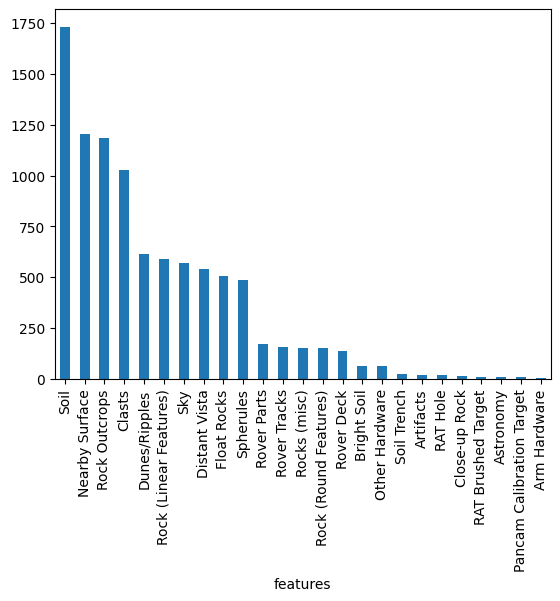

In [25]:
original_train_images['features'].explode().str.strip().value_counts().plot(kind='bar')

In [ ]:
plt.hist(train_data['images'], bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()